In [2]:
import sys
import time

def test_pytorch():
    print("=" * 50)
    print("       PyTorch 功能测试")
    print("=" * 50)

    # 1. 检查是否安装成功并获取版本
    try:
        import torch
        print(f"\n✅ [1/6] PyTorch 安装成功，版本: {torch.__version__}")
    except ImportError as e:
        print(f"❌ [1/6] PyTorch 未安装: {e}")
        return

    # 2. 检查 CUDA / GPU 可用性
    if torch.cuda.is_available():
        device = torch.device("cuda")
        print(f"✅ [2/6] CUDA 可用，GPU: {torch.cuda.get_device_name(0)}")
        print(f"       CUDA 版本: {torch.version.cuda}")
        print(f"       GPU 数量: {torch.cuda.device_count()}")
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        device = torch.device("mps")
        print(f"✅ [2/6] MPS (Apple Silicon) 可用")
    else:
        device = torch.device("cpu")
        print(f"⚠️  [2/6] CUDA/MPS 不可用，将使用 CPU 进行测试")

    # 3. 基本张量运算
    try:
        a = torch.tensor([[1.0, 2.0], [3.0, 4.0]], device=device)
        b = torch.tensor([[5.0, 6.0], [7.0, 8.0]], device=device)
        c = torch.matmul(a, b)
        expected = torch.tensor([[19.0, 22.0], [43.0, 50.0]], device=device)
        assert torch.allclose(c, expected), f"矩阵乘法结果不正确: {c}"
        print(f"✅ [3/6] 基本张量运算正常 (矩阵乘法验证通过)")
    except Exception as e:
        print(f"❌ [3/6] 基本张量运算失败: {e}")
        return

    # 4. 自动求导 (Autograd)
    try:
        x = torch.tensor(3.0, requires_grad=True, device=device)
        y = x ** 2 + 2 * x + 1  # y = x^2 + 2x + 1
        y.backward()
        # dy/dx = 2x + 2, 当 x=3 时, dy/dx = 8
        assert abs(x.grad.item() - 8.0) < 1e-5, f"梯度不正确: {x.grad.item()}"
        print(f"✅ [4/6] 自动求导正常 (dy/dx @ x=3 = {x.grad.item()})")
    except Exception as e:
        print(f"❌ [4/6] 自动求导失败: {e}")
        return

    # 5. 简单神经网络前向 + 反向传播
    try:
        import torch.nn as nn

        model = nn.Sequential(
            nn.Linear(10, 32),
            nn.ReLU(),
            nn.Linear(32, 2)
        ).to(device)

        dummy_input = torch.randn(4, 10, device=device)
        dummy_target = torch.randint(0, 2, (4,), device=device)

        # 前向传播
        output = model(dummy_input)
        loss = nn.CrossEntropyLoss()(output, dummy_target)

        # 反向传播
        loss.backward()

        # 检查梯度是否已计算
        has_grad = all(p.grad is not None for p in model.parameters())
        assert has_grad, "部分参数未计算出梯度"
        print(f"✅ [5/6] 神经网络前向/反向传播正常 (loss={loss.item():.4f})")
    except Exception as e:
        print(f"❌ [5/6] 神经网络测试失败: {e}")
        return

    # 6. 性能简易基准 (Benchmark)
    try:
        size = 1000
        m1 = torch.randn(size, size, device=device)
        m2 = torch.randn(size, size, device=device)

        # 预热
        torch.matmul(m1, m2)
        if device.type == "cuda":
            torch.cuda.synchronize()

        start = time.time()
        for _ in range(100):
            torch.matmul(m1, m2)
        if device.type == "cuda":
            torch.cuda.synchronize()
        elapsed = time.time() - start

        print(f"✅ [6/6] 性能基准: 100次 {size}x{size} 矩阵乘法耗时 {elapsed:.3f}s")
    except Exception as e:
        print(f"⚠️  [6/6] 性能基准测试跳过: {e}")

    print("\n" + "=" * 50)
    print("🎉 所有测试通过！PyTorch 可以正常使用。")
    print("=" * 50)


if __name__ == "__main__":
    test_pytorch()

       PyTorch 功能测试

✅ [1/6] PyTorch 安装成功，版本: 2.5.1+cu121
✅ [2/6] CUDA 可用，GPU: NVIDIA GeForce RTX 4060 Laptop GPU
       CUDA 版本: 12.1
       GPU 数量: 1
✅ [3/6] 基本张量运算正常 (矩阵乘法验证通过)
✅ [4/6] 自动求导正常 (dy/dx @ x=3 = 8.0)
✅ [5/6] 神经网络前向/反向传播正常 (loss=0.7914)
✅ [6/6] 性能基准: 100次 1000x1000 矩阵乘法耗时 0.035s

🎉 所有测试通过！PyTorch 可以正常使用。


数据生成完毕 → x:torch.Size([200, 1]),y:torch.Size([200, 1])
真实参数:w=3.0,b=2.0
Epoch   1|Loss:  297.6322|w: 1.9515|b: 0.0279
Epoch  50|Loss:    2.4635|w: 2.9938|b: 1.3871
Epoch 100|Loss:    1.8701|w: 2.9981|b: 1.9025
Epoch 150|Loss:    1.7911|w: 2.9997|b: 2.0907
Epoch 200|Loss:    1.7806|w: 3.0003|b: 2.1593
Epoch 250|Loss:    1.7791|w: 3.0005|b: 2.1844
Epoch 300|Loss:    1.7790|w: 3.0006|b: 2.1935

训练完成！
真实 w = 3.0000  →  估计 w = 3.0006
真实 b = 2.0000  →  估计 b = 2.1935
最终 Loss = 1.7790



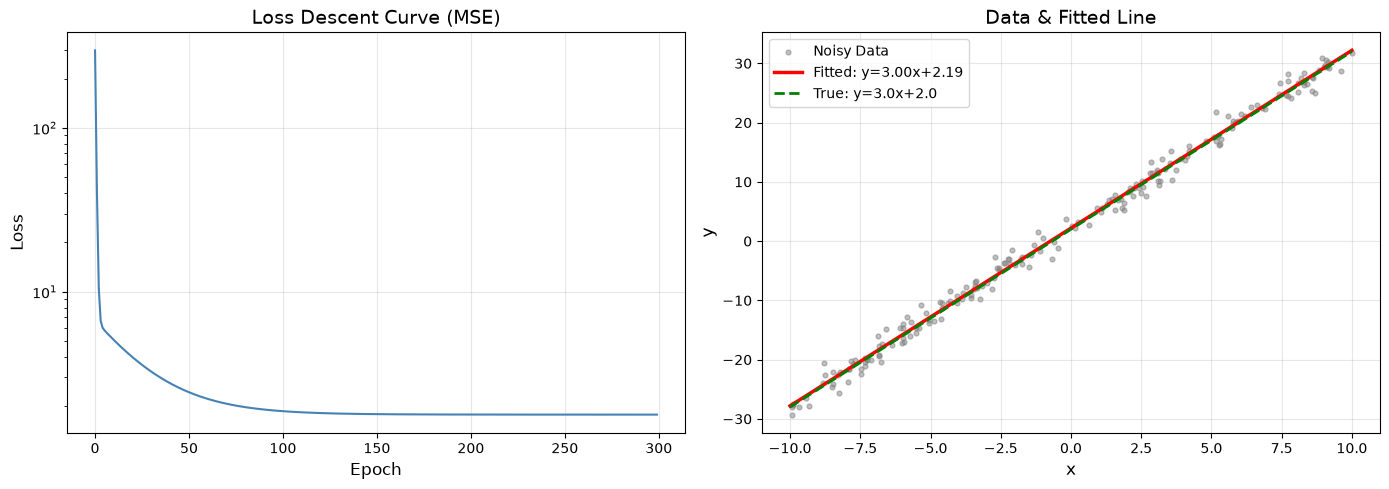

图片已保存为 autograd_linear_fit.png


In [ ]:
import torch
import matplotlib.pyplot as plt

#超参数
TRUE_W,TRUE_B = 3.0,2.0
N_SAMPLES = 200
NOISE_STD = 1.5
LR = 0.01
EPOCHS = 300
SEED = 42

torch.manual_seed(SEED)
#手动生成带噪声的线性数据
x = torch.rand(N_SAMPLES,1) * 20 - 10  #shape:(200,1)
noise = torch.randn(N_SAMPLES,1) * NOISE_STD 
y = TRUE_W * x + TRUE_B + noise

print(f'数据生成完毕 → x:{x.shape},y:{y.shape}')
print(f'真实参数:w={TRUE_W},b={TRUE_B}')

#初始化训练参数,需要梯度
w = torch.tensor(0.0,requires_grad=True)#权重，初始化为0
b = torch.tensor(0.0,requires_grad=True)#偏置，初始化为0

loss_history = []

for epoch in range(1,EPOCHS+1):
     #前向传播
     y_pred = w * x + b
     #计算损失
     loss = ((y_pred-y) ** 2).mean()
     #反向传播
     loss.backward()
    #手动梯度下降更新
     with torch.no_grad():
        
          w -= LR * w.grad
          b -= LR * b.grad
        #梯度清零
          w.grad.zero_()
          b.grad.zero_()
     #记录损失
     loss_history.append(loss.item())

     if epoch % 50 == 0 or epoch == 1:
          print(f'Epoch{epoch:4d}|Loss:{loss.item():10.4f}|'
                f'w:{w.item():7.4f}|b:{b.item():7.4f}')
print(f"\n{'='*50}")
print(f'训练完成！')
print(f'真实 w = {TRUE_W:.4f}  →  估计 w = {w.item():.4f}')
print(f'真实 b = {TRUE_B:.4f}  →  估计 b = {b.item():.4f}')
print(f'最终 Loss = {loss_history[-1]:.4f}')
print(f"{'='*50}\n")


fig,axes = plt.subplots(1,2,figsize=(14,5))
axes[0].plot(loss_history,color='steelblue',linewidth=1.5)
axes[0].set_title('Loss Descent Curve (MSE)',fontsize=14)
axes[0].set_xlabel('Epoch',fontsize=12)
axes[0].set_ylabel('Loss',fontsize=12)
axes[0].set_yscale('log')
axes[0].grid(True,alpha=0.3)

axes[1].scatter(x.numpy(),y.numpy(),s=12,alpha=0.5,label='Noisy Data',color='gray')
x_line = torch.linspace(-10,10,100).unsqueeze(1)
y_fit = w.item() * x_line + b.item()
y_true = TRUE_W * x_line + TRUE_B
axes[1].plot(x_line.numpy(),y_fit.numpy(),linewidth=2.5,color='red',label=f'Fitted: y={w.item():.2f}x+{b.item():.2f}')
axes[1].plot(x_line.numpy(),y_true.numpy(),linewidth=2.0,color='green',linestyle='--',label=f'True: y={TRUE_W}x+{TRUE_B}')
axes[1].set_title('Data & Fitted Line',fontsize=14)
axes[1].set_xlabel('x',fontsize=12)
axes[1].set_ylabel('y',fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True,alpha=0.3)

plt.tight_layout()
plt.savefig('autograd_linear_fit.png',dpi=150)
plt.show()
print('图片已保存为 autograd_linear_fit.png')





初始化参数: w=-0.4085, b=0.3675

Epoch    1 | Loss:   381.9893 | w:  1.8122 | b:  0.3860
Epoch   50 | Loss:     2.2577 | w:  2.9949 | b:  1.5200
Epoch  100 | Loss:     1.8427 | w:  2.9985 | b:  1.9510
Epoch  150 | Loss:     1.7874 | w:  2.9999 | b:  2.1084
Epoch  200 | Loss:     1.7801 | w:  3.0003 | b:  2.1658
Epoch  250 | Loss:     1.7791 | w:  3.0005 | b:  2.1868
Epoch  300 | Loss:     1.7790 | w:  3.0006 | b:  2.1944

✅ 模型参数已保存到 linear_model.pth

加载后的参数验证:
  w = 3.0006 (真实值: 3.0)
  b = 2.1944 (真实值: 2.0)



C:\Users\yuhao.bian\AppData\Local\Temp\ipykernel_12008\4175856738.py:49: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load(MODEL_PATH))


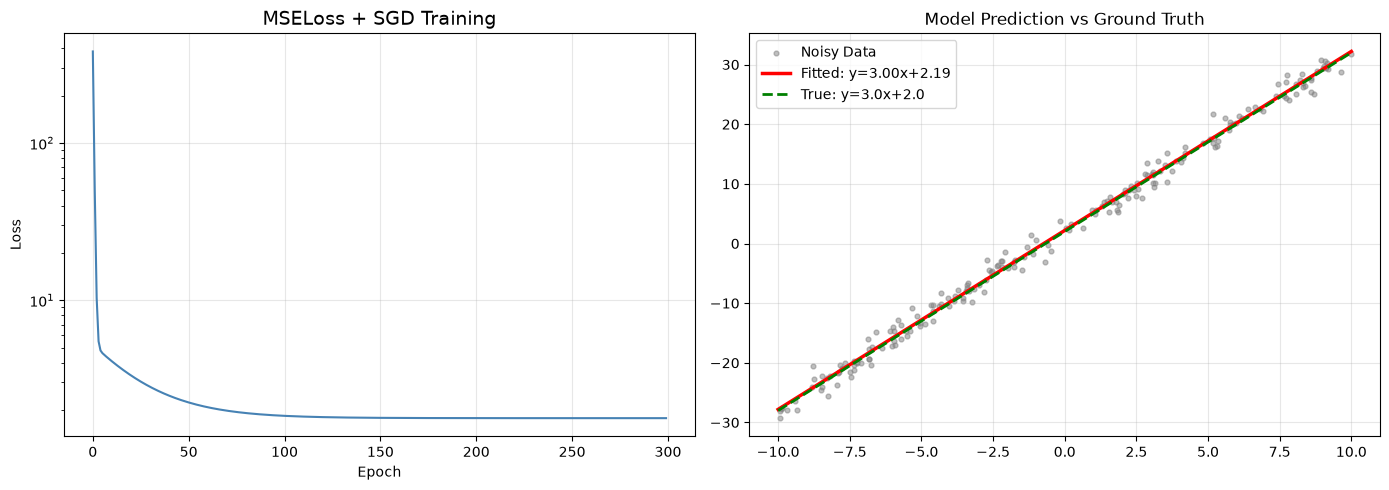

图片已保存为 sgd_training_result.png


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

#超参数
TRUE_W,TRUE_B = 3.0,2.0
N_SAMPLES = 200
NOISE_STD = 1.5
LR = 0.01
EPOCHS = 300
SEED = 42
MODEL_PATH = 'linear_model.pth'
#随机种子确保可重复
torch.manual_seed(SEED)
#生成数据
x = torch.rand(N_SAMPLES,1)*20-10
noise = torch.randn(N_SAMPLES,1)*NOISE_STD
y = TRUE_W * x + TRUE_B + noise
#定义模型、损失函数、优化器
model = nn.Linear(1,1)
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(),lr=LR)

print(f"初始化参数: w={model.weight.item():.4f}, b={model.bias.item():.4f}\n")
#记录损失
loss_history = []

for epoch in range(1,EPOCHS+1):
#前向传播
    y_pred = model(x)
    #计算损失
    loss = criterion(y_pred,y)
#反向传播+参数更新
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())
    if epoch % 50 == 0 or epoch == 1:
        print(f"Epoch {epoch:4d} | Loss: {loss.item():10.4f} | "
              f"w: {model.weight.item():7.4f} | b: {model.bias.item():7.4f}")
    
#保存模型参数
torch.save(model.state_dict(),MODEL_PATH)
print(f"\n✅ 模型参数已保存到 {MODEL_PATH}")

#验证加载
loaded_model = nn.Linear(1,1)
loaded_model.load_state_dict(torch.load(MODEL_PATH))
loaded_model.eval()

print(f"\n{'='*50}")
print(f"加载后的参数验证:")
print(f"  w = {loaded_model.weight.item():.4f} (真实值: {TRUE_W})")
print(f"  b = {loaded_model.bias.item():.4f} (真实值: {TRUE_B})")
print(f"{'='*50}\n")

fig,axes = plt.subplots(1,2,figsize=(14,5))

# 损失曲线
axes[0].plot(loss_history, color='steelblue', linewidth=1.5)
axes[0].set_title('MSELoss + SGD Training', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

# 拟合直线
axes[1].scatter(x.numpy(), y.numpy(), s=12, alpha=0.5, color='gray', label='Noisy Data')
x_line = torch.linspace(-10, 10, 100).unsqueeze(1)
y_fit  = loaded_model(x_line).detach().numpy()
y_true = TRUE_W * x_line.numpy() + TRUE_B

axes[1].plot(x_line.numpy(), y_fit, linewidth=2.5, color='red', 
             label=f'Fitted: y={loaded_model.weight.item():.2f}x+{loaded_model.bias.item():.2f}')
axes[1].plot(x_line.numpy(), y_true, linewidth=2.0, color='green', linestyle='--',
             label=f'True: y={TRUE_W}x+{TRUE_B}')
axes[1].set_title('Model Prediction vs Ground Truth')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sgd_training_result.png', dpi=150)
plt.show()
print("图片已保存为 sgd_training_result.png")


In [1]:
import torch
x = torch.tensor(2.0,requires_grad=True)

y = x * x
z = y + x

z.backward()
print(x.grad)


tensor(5.)


NumPy 从零实现结果
真实参数:  w = 3.5, b = 2.0
学习参数:  w = 3.5499, b = 2.0448
最终损失:  0.120066


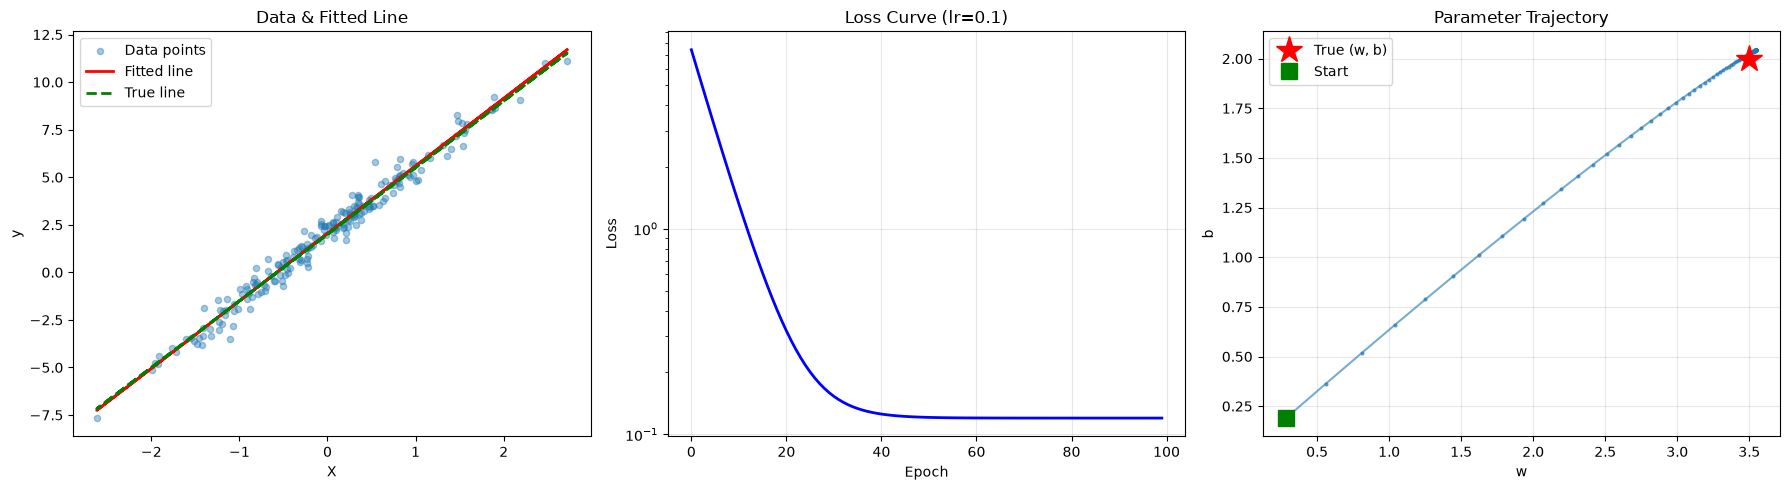

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. 生成模拟数据
# ============================================================
np.random.seed(42)
n_samples = 200

# 真实参数: y = 3.5 * x + 2.0 + noise
X = np.random.randn(n_samples, 1)          # 形状 (200, 1)
true_w, true_b = 3.5, 2.0
noise = np.random.randn(n_samples, 1) * 0.5
y = true_w * X + true_b + noise            # 形状 (200, 1)

# ============================================================
# 2. 模型 / 损失 / 梯度 的定义
# ============================================================
def predict(X, w, b):
    """线性模型: y_hat = Xw + b"""
    return X @ w + b                        # 矩阵乘法 (n,1)@(1,1) + (1,)

def mse_loss(y_pred, y_true):
    """均方误差损失: L = 1/(2n) * Σ(y_hat - y)^2"""
    n = y_true.shape[0]
    return np.sum((y_pred - y_true) ** 2) / (2 * n)

def compute_gradients(X, y_pred, y_true):
    """
    计算梯度:
      dw = (1/n) * X^T @ (y_hat - y)
      db = (1/n) * Σ(y_hat - y)
    """
    n = y_true.shape[0]
    error = y_pred - y_true                 # (n, 1)
    dw = (X.T @ error) / n                 # (1, 1)
    db = np.sum(error) / n                 # scalar
    return dw, db

# ============================================================
# 3. 梯度下降训练循环
# ============================================================
def train_numpy(X, y, lr=0.1, epochs=100):
    """从零训练，返回参数历史和损失历史"""
    w = np.random.randn(1, 1) * 0.01       # 初始化权重
    b = np.zeros(1)                         # 初始化偏置

    loss_history = []
    w_history = []
    b_history = []

    for epoch in range(epochs):
        # 前向传播
        y_pred = predict(X, w, b)

        # 计算损失
        loss = mse_loss(y_pred, y)

        # 反向传播（计算梯度）
        dw, db = compute_gradients(X, y_pred, y)

        # 参数更新
        w -= lr * dw
        b -= lr * db

        # 记录
        loss_history.append(loss)
        w_history.append(w.item())
        b_history.append(b.item())

    return w, b, loss_history, w_history, b_history

# ============================================================
# 4. 运行训练
# ============================================================
w_final, b_final, losses, w_hist, b_hist = train_numpy(X, y, lr=0.1, epochs=100)

print(f"{'='*50}")
print(f"NumPy 从零实现结果")
print(f"{'='*50}")
print(f"真实参数:  w = {true_w}, b = {true_b}")
print(f"学习参数:  w = {w_final.item():.4f}, b = {b_final.item():.4f}")
print(f"最终损失:  {losses[-1]:.6f}")

# ============================================================
# 5. 可视化
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 子图1: 数据 + 拟合线
axes[0].scatter(X, y, alpha=0.4, s=20, label='Data points')
axes[0].plot(X, w_final * X + b_final, 'r-', linewidth=2, label='Fitted line')
axes[0].plot(X, true_w * X + true_b, 'g--', linewidth=2, label='True line')
axes[0].set_xlabel('X'); axes[0].set_ylabel('y')
axes[0].set_title('Data & Fitted Line'); axes[0].legend()

# 子图2: 损失曲线
axes[1].plot(losses, color='blue', linewidth=2)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].set_title('Loss Curve (lr=0.1)')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

# 子图3: 参数收敛轨迹
axes[2].plot(w_hist, b_hist, 'o-', markersize=2, alpha=0.6)
axes[2].plot(true_w, true_b, 'r*', markersize=20, label='True (w, b)')
axes[2].plot(w_hist[0], b_hist[0], 'gs', markersize=12, label='Start')
axes[2].set_xlabel('w'); axes[2].set_ylabel('b')
axes[2].set_title('Parameter Trajectory'); axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('numpy_linear_regression.png', dpi=150, bbox_inches='tight')
plt.show()

初始 w: 0.5841, 初始 b: -0.3787

结果对比
                            NumPy      PyTorch         True
--------------------------------------------------------
Weight (w)                 3.5499       3.5504       3.5000
Bias (b)                   2.0448       2.0450       2.0000
Final Loss               0.120066     0.120066            —


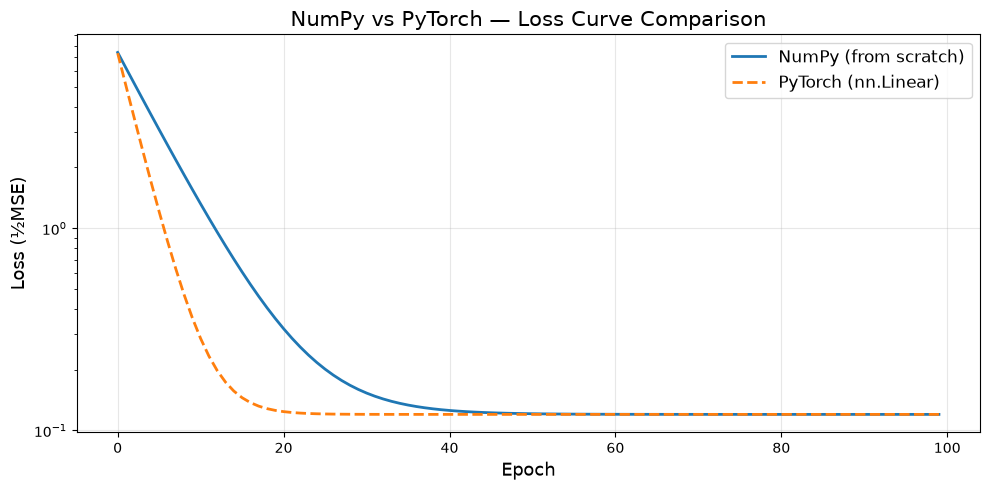

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim

# ============================================================
# 1. 数据准备 (复用 NumPy 生成的数据)
# ============================================================
X_tensor = torch.tensor(X, dtype=torch.float32)     # (200, 1)
y_tensor = torch.tensor(y, dtype=torch.float32)     # (200, 1)

# ============================================================
# 2. 定义模型 (一行搞定！)
# ============================================================
model = nn.Linear(in_features=1, out_features=1)    # 等价于 y = Xw + b

# 查看初始参数
print(f"初始 w: {model.weight.item():.4f}, 初始 b: {model.bias.item():.4f}")

# ============================================================
# 3. 定义损失函数 + 优化器
# ============================================================
criterion = nn.MSELoss()                            # PyTorch 的 MSE 没有 1/2 系数
optimizer = optim.SGD(model.parameters(), lr=0.1)

# ============================================================
# 4. 训练循环
# ============================================================
torch.manual_seed(42)
# 重新初始化模型以获得公平对比
model = nn.Linear(1, 1)
nn.init.normal_(model.weight, std=0.01)
nn.init.zeros_(model.bias)

optimizer = optim.SGD(model.parameters(), lr=0.1)

loss_history_pt = []
epochs = 100

for epoch in range(epochs):
    # 前向传播
    y_pred = model(X_tensor)                        # 等价于 X @ w + b

    # 计算损失
    loss = criterion(y_pred, y_tensor)
    # 注意: nn.MSELoss 默认是 mean((y_pred - y)^2), 没有 1/2
    # 所以数值上约为 NumPy 版本的 2 倍，但收敛行为完全一致

    # 反向传播 + 参数更新
    optimizer.zero_grad()                           # 清零梯度 (PyTorch 默认累加)
    loss.backward()                                 # 自动计算梯度
    optimizer.step()                                # 更新参数: w -= lr * w.grad

    loss_history_pt.append(loss.item())

# ============================================================
# 5. 结果对比
# ============================================================
w_pt = model.weight.item()
b_pt = model.bias.item()

print(f"\n{'='*50}")
print(f"结果对比")
print(f"{'='*50}")
print(f"{'':20s} {'NumPy':>12s} {'PyTorch':>12s} {'True':>12s}")
print(f"{'-'*56}")
print(f"{'Weight (w)':20s} {w_final.item():12.4f} {w_pt:12.4f} {true_w:12.4f}")
print(f"{'Bias (b)':20s} {b_final.item():12.4f} {b_pt:12.4f} {true_b:12.4f}")
print(f"{'Final Loss':20s} {losses[-1]:12.6f} {loss_history_pt[-1]/2:12.6f} {'—':>12s}")
# 注: PyTorch loss / 2 是为了和 NumPy 的 1/(2n) 对齐

# ============================================================
# 6. 损失曲线对比
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(losses, label='NumPy (from scratch)', linewidth=2)
ax.plot([l/2 for l in loss_history_pt], label='PyTorch (nn.Linear)', linewidth=2, linestyle='--')
ax.set_xlabel('Epoch', fontsize=13)
ax.set_ylabel('Loss (½MSE)', fontsize=13)
ax.set_title('NumPy vs PyTorch — Loss Curve Comparison', fontsize=15)
ax.set_yscale('log')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('numpy_vs_pytorch.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\yuhao.bian\AppData\Local\Temp\ipykernel_14404\2114300229.py:66: UserWarning: Glyph 128165 (\N{COLLISION SYMBOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\yuhao.bian\AppData\Local\Temp\ipykernel_14404\2114300229.py:67: UserWarning: Glyph 128165 (\N{COLLISION SYMBOL}) missing from font(s) DejaVu Sans.
  plt.savefig('learning_rate_exploration.png', dpi=150, bbox_inches='tight')
d:\pythonprojects\practice-github\torch_final\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128165 (\N{COLLISION SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


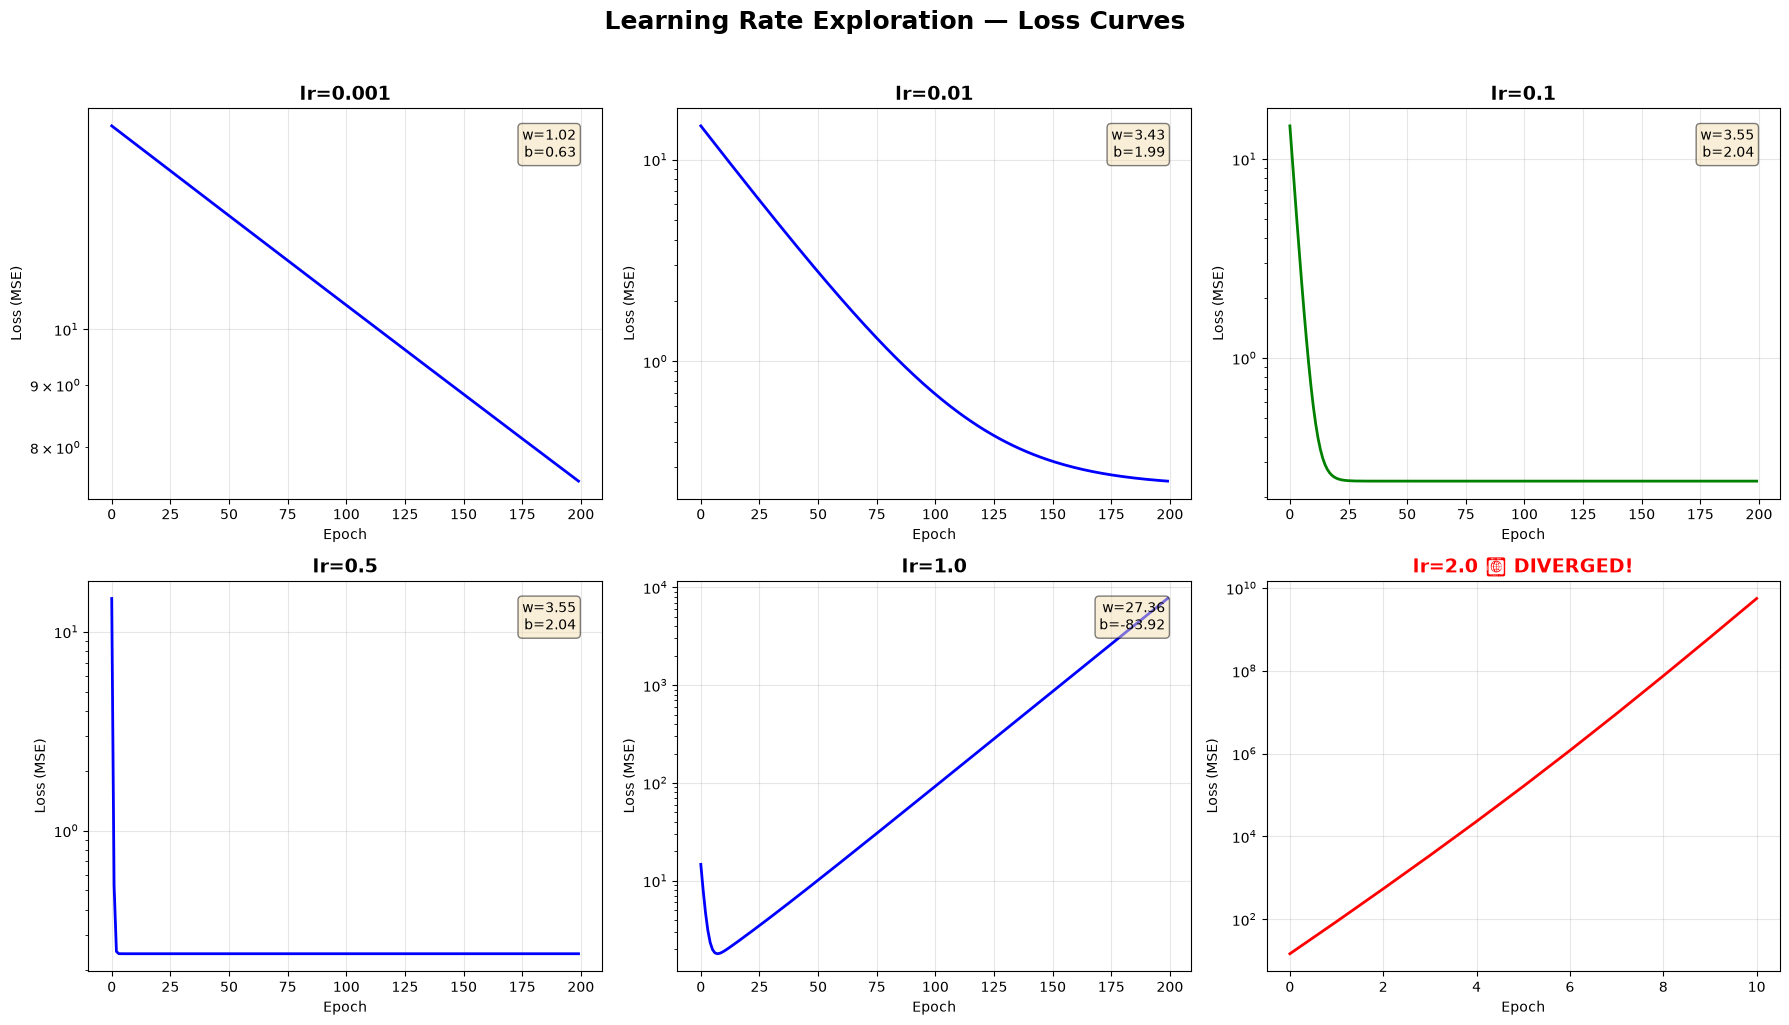


学习率探索结果汇总
      lr | 状态         |       最终 w |       最终 b |      最终 Loss
----------------------------------------------------------------------
   0.001 | ✅ 收敛       |     1.0183 |     0.6347 |     7.503279
   0.010 | ✅ 收敛       |     3.4326 |     1.9945 |     0.254678
   0.100 | ✅ 收敛       |     3.5504 |     2.0450 |     0.240133
   0.500 | ✅ 收敛       |     3.5504 |     2.0450 |     0.240133
   1.000 | ✅ 收敛       |    27.3619 |   -83.9221 |  7695.888672
   2.000 | 💥 发散       |  4085.1924 | 223063.5312 | 5579702784.000000


In [5]:
# ============================================================
# 探索不同学习率对损失曲线的影响
# ============================================================
learning_rates = [0.001, 0.01, 0.1, 0.5, 1.0, 2.0]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

results = {}

for idx, lr in enumerate(learning_rates):
    # 每次重新初始化模型
    torch.manual_seed(42)
    model_lr = nn.Linear(1, 1)
    nn.init.normal_(model_lr.weight, std=0.01)
    nn.init.zeros_(model_lr.bias)

    optimizer = optim.SGD(model_lr.parameters(), lr=lr)
    loss_hist = []

    diverged = False
    for epoch in range(200):
        y_pred = model_lr(X_tensor)
        loss = criterion(y_pred, y_tensor)

        # 检测发散 (NaN 或爆炸)
        if torch.isnan(loss) or loss.item() > 1e10:
            diverged = True
            break

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        loss_hist.append(loss.item())

    results[lr] = {
        'losses': loss_hist,
        'diverged': diverged,
        'final_w': model_lr.weight.item(),
        'final_b': model_lr.bias.item()
    }

    # 绘图
    ax = axes[idx]
    color = 'red' if diverged else ('green' if lr == 0.1 else 'blue')
    label = f'lr={lr}' + (' 💥 DIVERGED!' if diverged else '')

    ax.plot(loss_hist, color=color, linewidth=2)
    ax.set_title(label, fontsize=14, fontweight='bold',
                 color='red' if diverged else 'black')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss (MSE)')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)

    # 标注最终参数
    if not diverged and len(loss_hist) > 0:
        ax.annotate(
            f'w={results[lr]["final_w"]:.2f}\nb={results[lr]["final_b"]:.2f}',
            xy=(0.95, 0.95), xycoords='axes fraction',
            horizontalalignment='right', verticalalignment='top',
            fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
        )

plt.suptitle('Learning Rate Exploration — Loss Curves', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('learning_rate_exploration.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 汇总表格
# ============================================================
print(f"\n{'='*70}")
print(f"学习率探索结果汇总")
print(f"{'='*70}")
print(f"{'lr':>8s} | {'状态':10s} | {'最终 w':>10s} | {'最终 b':>10s} | {'最终 Loss':>12s}")
print(f"{'-'*70}")
for lr, res in results.items():
    status = "💥 发散" if res['diverged'] else ("✅ 收敛" if len(res['losses']) > 150 else "⚠️ 未完成")
    final_loss = res['losses'][-1] if res['losses'] else float('inf')
    print(f"{lr:8.3f} | {status:10s} | {res['final_w']:10.4f} | {res['final_b']:10.4f} | {final_loss:12.6f}")

images shape: torch.Size([16, 1, 28, 28])
labels:       tensor([3, 7, 4, 1, 1, 4, 0, 2, 7, 3, 6, 4, 9, 4, 7, 0])
pixel range:  [-1.00, 1.00]
denorm range: [0.00, 1.00]


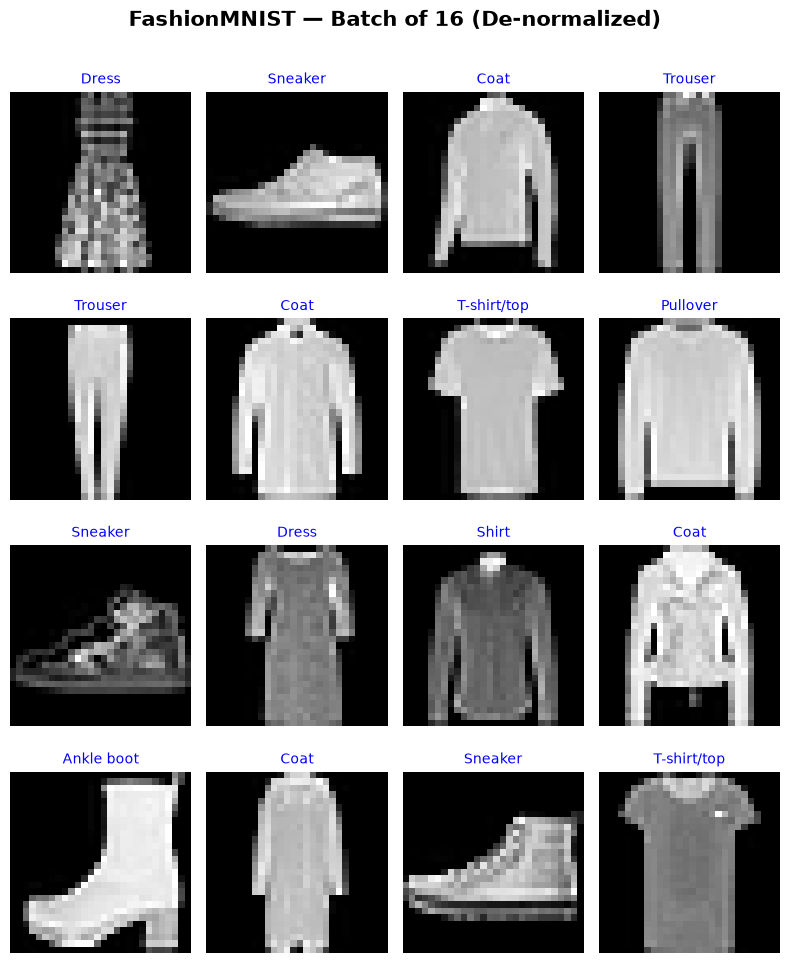

In [8]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,))
])

dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    download = True,
    transform=transform
)

dataloader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2,
)

images,labels=next(iter(dataloader))
print(f'images shape: {images.shape}')
print(f'labels:       {labels}')
print(f'pixel range:  [{images.min():.2f}, {images.max():.2f}]')


def denormalize(tensor,mean=0.5,std=0.5):
    return tensor * std + mean
images_denorm = denormalize(images)
print(f'denorm range: [{images_denorm.min():.2f}, {images_denorm.max():.2f}]')

CLASS_NAMES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal',      'Shirt',   'Sneaker',  'Bag',   'Ankle boot'
]

fig, axes = plt.subplots(4, 4, figsize=(8, 10))
fig.suptitle('FashionMNIST — Batch of 16 (De-normalized)', fontsize=15, fontweight='bold')

for i, ax in enumerate(axes.flat):
    # .squeeze() 去掉通道维度: (1, 28, 28) → (28, 28)
    img = images_denorm[i].squeeze().numpy()

    ax.imshow(img, cmap='gray')
    ax.set_title(CLASS_NAMES[labels[i]], fontsize=10, color='blue')
    ax.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.savefig('fashionmnist_batch.png', dpi=150)
plt.show()